In [1]:

import sys
sys.path.insert(0, 'src')
from instance_generator import InstanceGenerator

from farmers_intermediaries import Intermediary, Farmer, Mill, Instance
import pandas as pd
from pprint import pprint
import yaml
import pickle
import folium
import numpy as np

from pyproj import Transformer
from collections import defaultdict

INDO_CRS = "EPSG:23867"
LL_CRS = "EPSG:4326"

In [2]:
ints_df = pd.read_csv('data/ints.csv')
mills_df = pd.read_csv('data/mills.csv')
farmers_df = pd.read_csv('data/farmers.csv')

In [3]:
with open("../FactoredPlatformSolver/data/graph_0-14960_00.pickle", 'rb') as pickle_file:
    G = pickle.load(pickle_file)

/var/folders/7_/y4vpj6ln7b90djzq_hscbgyr0000gn/T/ipykernel_74416/2103481861.py:2: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  G = pickle.load(pickle_file)


In [4]:
ig = InstanceGenerator(farmers_df, ints_df)

/Users/nachatjatusripitak/Desktop/Paper Revision/SyntheticInstanceGenerator/src/instance_generator.py:88: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  G = pickle.load(f)


In [11]:
ig.gen_ints(1)

In [17]:
from sklearn.cluster import KMeans

In [27]:
N_CLUSTERS = 3
int_pickup_schedules = {}

for int_id, data in ig.ints.items():
    k = N_CLUSTERS

    X = np.array([f['xy'] for f in ig.farmers[int_id].values()])

    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto").fit(X)

    days = np.random.choice(13, size=N_CLUSTERS, replace=False)

    mapping = {label: value for label, value in enumerate(days)}

    print(kmeans.labels_, mapping)

[0 1 0 2 1 0 1 2 2 1] {0: np.int64(2), 1: np.int64(3), 2: np.int64(4)}
[1 2 1 1 2 0 1 1 1 1] {0: np.int64(9), 1: np.int64(1), 2: np.int64(10)}
[2 2 2 2 1 0 0 1 2 2] {0: np.int64(9), 1: np.int64(3), 2: np.int64(1)}
[0 0 0 2 0 0 2 0 1 1] {0: np.int64(10), 1: np.int64(8), 2: np.int64(11)}
[2 2 2 0 1 0 1 0 0 2] {0: np.int64(12), 1: np.int64(11), 2: np.int64(9)}
[2 0 1 1 2 0 2 0 0 2] {0: np.int64(12), 1: np.int64(8), 2: np.int64(1)}
[0 1 2 1 1 0 0 2 2 1] {0: np.int64(10), 1: np.int64(1), 2: np.int64(3)}
[2 2 1 1 1 0 0 1 0 1] {0: np.int64(10), 1: np.int64(4), 2: np.int64(3)}
[2 2 2 2 2 0 1 0 2 2] {0: np.int64(9), 1: np.int64(11), 2: np.int64(6)}
[2 1 1 2 0 0 2 2 2 2] {0: np.int64(12), 1: np.int64(9), 2: np.int64(11)}


In [80]:
import random

def assign_people_to_days_cyclic_perturbed(
    cluster_assignments,
    cluster_to_day,
    total_days,
    cycle_length=14,
    max_shift=1,
    seed=None
):
    """
    Adds +/- max_shift day perturbation to cyclic schedule.

    Returns:
        dict: day -> list of person indices
    """
    if seed is not None:
        random.seed(seed)

    # Step 1: base cycle
    base = {day: [] for day in range(cycle_length)}
    for person_idx, cluster in enumerate(cluster_assignments):
        if cluster not in cluster_to_day:
            continue
        base_day = cluster_to_day[cluster]
        base[base_day].append(person_idx)

    # Step 2: initialize full schedule
    full_schedule = {day: [] for day in range(total_days)}

    # Step 3: assign with perturbation
    for day in range(total_days):
        base_day = day % cycle_length
        for person in base[base_day]:
            shift = random.randint(-max_shift, max_shift)
            new_day = day + shift

            # clamp to valid range (alternative: wrap with modulo)
            if 0 <= new_day < total_days:
                full_schedule[new_day].append(person)

    return full_schedule

assign_people_to_days_cyclic_perturbed(kmeans.labels_, mapping, 14)

{0: [],
 1: [],
 2: [],
 3: [],
 4: [],
 5: [],
 6: [],
 7: [],
 8: [],
 9: [1, 2],
 10: [3, 9],
 11: [6],
 12: [0, 7, 8, 4, 5],
 13: []}

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='talk', style='dark')

/var/folders/7_/y4vpj6ln7b90djzq_hscbgyr0000gn/T/ipykernel_62506/596643824.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


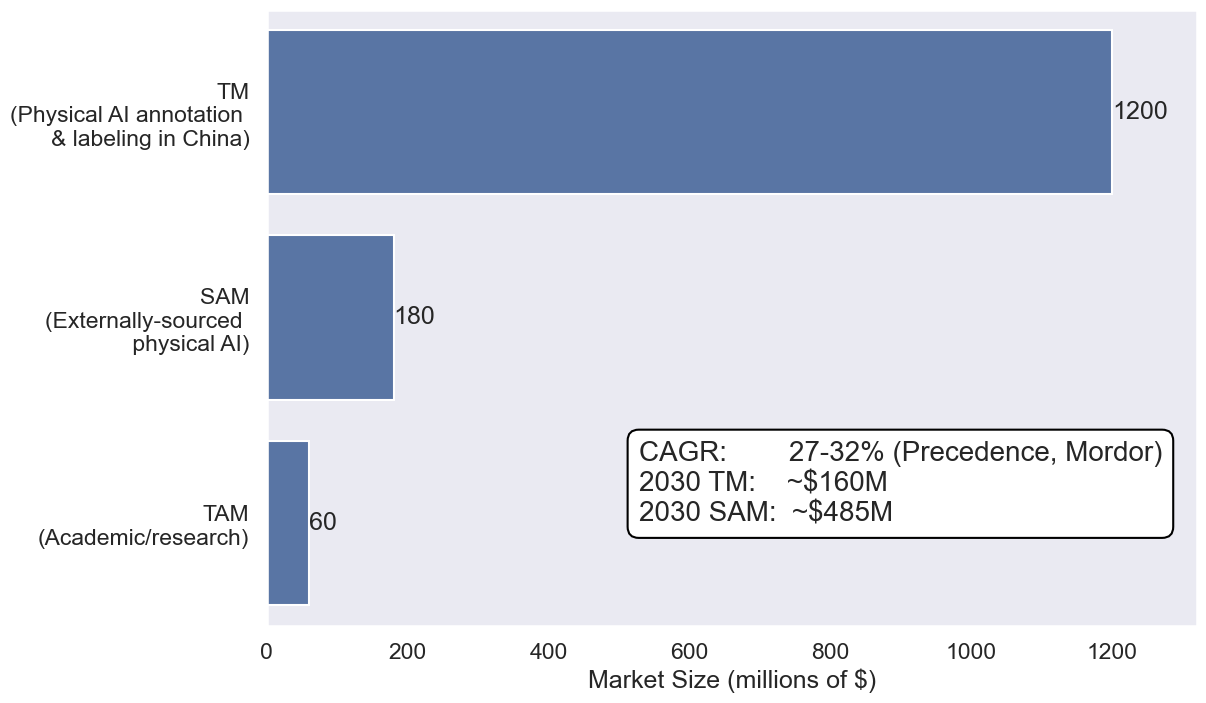

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

y = [60, 180, 1200]
y.reverse()
x = ['TM', 'SAM', 'TAM']
x.reverse()

df = pd.DataFrame(y, x, columns=['Size'])

fig = plt.figure(figsize=(12, 8))
ax = sns.barplot(data=df, x='Size', y=df.index)

ax.set_xlim(0, df['Size'].max() * 1.1)

plt.xlabel('Market Size (millions of $)')
plt.ylabel(None)

labels = ['TM\n(Physical AI annotation \n& labeling in China)',
          'SAM\n(Externally-sourced \n physical AI)',
          'TAM\n(Academic/research)']

ax.set_yticklabels(labels)

ax.text(
    0.4, 0.3,                      # (x, y) in axes coordinates (0–1)
    "CAGR:        27-32% (Precedence, Mordor)\n2030 TM:    ~$160M\n2030 SAM:  ~$485M",
    transform=ax.transAxes,
    fontsize=20,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='black'
    )
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()